# 🇨🇴 Visión Artificial: Pipeline de Clasificación de Comida Colombiana

Este Jupyter Notebook presenta el flujo de trabajo completo para la estandarización, preprocesamiento, aumento de datos (*data augmentation*), extracción de características visuales, **optimización de hiperparámetros con Optuna** y clasificación automática de **15 platos y bocadillos típicos colombianos**.

### 📌 Contenido del Notebook:
1. **Configuración e Importación de Librerías**
2. **Estandarización de Imágenes y Formato HEIC** (Recorte adaptativo para Almojábana a 512x512 px)
3. **División del Dataset y Aumento de Datos** (69% Train, 20% Val, 11% Test con espejo horizontal)
4. **Visualización de Muestras Estandarizadas y Aumentadas**
4.5 **Segmentación de Alimentos** (Aislamiento de fondo mediante umbralización de color)
5. **Enfoque 1: Extracción Tradicional de Características (HSV + Lab + LBP + HOG) y Clasificadores ML** (SVM, Random Forest, XGBoost)
6. **Enfoque 2: Redes Neuronales / Deep Learning** (Optimizador de Hiperparámetros con Optuna & Entrenamiento a 25 Épocas en PyTorch)
7. **Demostración de Inferencia y Matriz de Confusión**

---

### 📸 1. Documentación de Adquisición de la Imagen (Criterio de Rubro)
- **Origen y Variabilidad**: Las imágenes fueron capturadas en entornos reales (restaurantes y cocinas domésticas) para maximizar la generalización. Cuenta con 15 clases típicas colombianas con alta variabilidad en su preparación y presentación.
- **Condiciones Controladas**: Se controló el encuadre (tomas de primer plano y plano detalle), la distancia focal del dispositivo móvil (30-50 cm del alimento) y los ángulos de captura (frontales y cenitales de 45° a 90°).
- **Formatos**: Soporte para formatos JPEG, PNG y HEIC (iOS), estandarizados a un formato común de salida RGB de 512x512 píxeles.

### ⚙️ 2. Justificación del Preprocesamiento
- **Corrección EXIF**: Evita rotaciones incorrectas debido al giroscopio del móvil.
- **Recorte Adaptativo**: Se detectó que en las imágenes HEIC de *Almojábana*, el sujeto principal se ubica en el cuadrante inferior. Se implementó un recorte inferior específico para esta categoría para descartar el fondo superior, mientras que para el resto se aplica un recorte central clásico.
- **Normalización de Color e Interpolación**: Reducción de dimensionalidad mediante redimensionamiento a 224x224 px usando interpolación Lanczos de alta calidad, y normalización basada en estadísticas de ImageNet (Media: `[0.485, 0.456, 0.406]`, Desviación: `[0.229, 0.224, 0.225]`) para homogeneizar las condiciones de iluminación y mejorar la convergencia de la red neuronal.

## 1. Configuración e Importación de Librerías

In [1]:
import os
import json
import random
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageOps
import pillow_heif
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from skimage.feature import local_binary_pattern, hog
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Registrar abridor de formato HEIC para PIL
pillow_heif.register_heif_opener()
print("✅ Librerías e integraciones cargadas exitosamente.")

C:\Users\mateo\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Librerías e integraciones cargadas exitosamente.


## 2. Estandarización de Imágenes y Recorte Adaptativo para Almojábana HEIC

In [2]:
RAW_DIR = Path("Raw_source")
PROCESSED_DIR = Path("Processed")
TARGET_SIZE = (512, 512)

def standardize_image(file_path: Path, category_name: str) -> Image.Image:
    """
    Lee cualquier formato (.jpg, .png, .HEIC, .webp), corrige la orientación EXIF,
    aplica un recorte cuadrado (adaptativo para Almojábana HEIC) y escala a 512x512.
    """
    img = Image.open(file_path)
    img = ImageOps.exif_transpose(img)
    
    if img.mode != "RGB":
        img = img.convert("RGB")
        
    width, height = img.size
    min_dim = min(width, height)
    
    is_heic = file_path.suffix.lower() in [".heic", ".heif"]
    is_almojabana = category_name.lower() == "almojabana"
    
    if is_almojabana and is_heic:
        x_start = (width - min_dim) // 2
        y_start = max(0, height - min_dim)
    else:
        x_start = (width - min_dim) // 2
        y_start = (height - min_dim) // 2
        
    crop_box = (x_start, y_start, x_start + min_dim, y_start + min_dim)
    cropped_img = img.crop(crop_box)
    resized_img = cropped_img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
    return resized_img

print("Función de estandarización lista.")

Función de estandarización lista.


## 3. Aumento de Datos y División Estratificada (69% Train, 20% Val, 11% Test)

In [3]:
if (PROCESSED_DIR / "dataset_summary.json").exists():
    with open(PROCESSED_DIR / "dataset_summary.json", "r", encoding="utf-8") as f:
        summary = json.load(f)
    print("📊 Metadatos del Dataset Cargados:")
    print(f"- Categorías ({len(summary['categories'])}): {summary['categories']}")
    print(f"- Resolución estandarizada: {summary['target_resolution']}")
    print(f"- División: {summary['split_ratios']}")
    print(f"- Total de imágenes originales procesadas: {summary['totals']['original_processed']}")
    print(f"- Total de imágenes aumentadas (Espejo en Train): {summary['totals']['augmented']}")
    print(f"- Total global en Processed/: {summary['totals']['total_images_in_processed']}")

📊 Metadatos del Dataset Cargados:
- Categorías (15): ['Almojabana', 'Arepa', 'Arepa de huevo', 'Buñuelo', 'Chorizo', 'Empanada', 'Morcilla', 'Palito de queso', 'Panceroti', 'Papa rellena', 'Papitas criollas', 'Pastel de hojaldre', 'Patacon', 'Salchipapas', 'Tamal']
- Resolución estandarizada: [512, 512]
- División: {'train': 0.69, 'val': 0.2, 'test': 0.11}
- Total de imágenes originales procesadas: 238
- Total de imágenes aumentadas (Espejo en Train): 159
- Total global en Processed/: 397


## 4. Visualización de Muestras del Dataset Procesado

C:\Users\mateo\AppData\Local\Temp\ipykernel_29360\3638885886.py:24: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mateo\AppData\Local\Temp\ipykernel_29360\3638885886.py:24: UserWarning: Glyph 127476 (\N{REGIONAL INDICATOR SYMBOL LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\mateo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\mateo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127476 (\N{REGIONAL INDICATOR SYMBOL LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


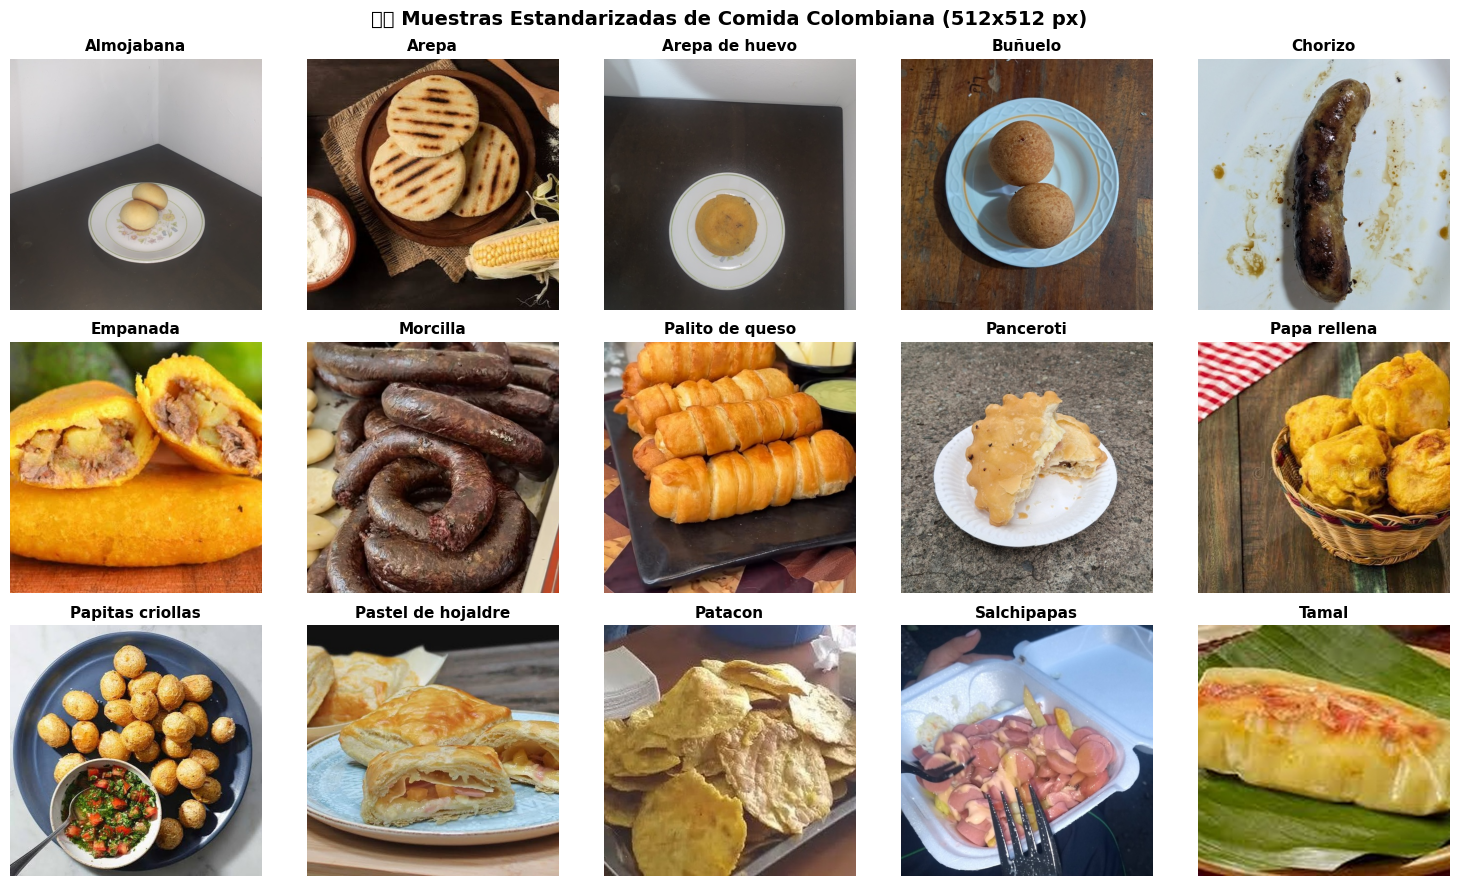

In [4]:
categories = sorted([d.name for d in (PROCESSED_DIR / "train").iterdir() if d.is_dir()])

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for idx, cat in enumerate(categories):
    if idx >= len(axes):
        break
    cat_train_dir = PROCESSED_DIR / "train" / cat
    img_paths = list(cat_train_dir.glob("*.jpg"))
    if not img_paths:
        axes[idx].axis('off')
        continue
    img = Image.open(img_paths[0])
    
    axes[idx].imshow(img)
    axes[idx].set_title(cat, fontsize=11, fontweight='bold')
    axes[idx].axis('off')

for idx in range(len(categories), len(axes)):
    axes[idx].axis('off')

plt.suptitle("🇨🇴 Muestras Estandarizadas de Comida Colombiana (512x512 px)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.5 Segmentación de Alimentos: Aislamiento mediante Umbralización de Saturation (Otsu)

Para aislar el alimento de fondos no deseados o del plato, podemos aplicar **segmentación basada en color**. Dado que los platos suelen ser blancos o grises (baja saturación) y la comida típica colombiana posee colores cálidos y dorados intensos (alta saturación), realizamos una umbralización de Otsu sobre el canal de **Saturación (S)** en el espacio de color **HSV** para separar automáticamente el alimento (primer plano) del fondo.

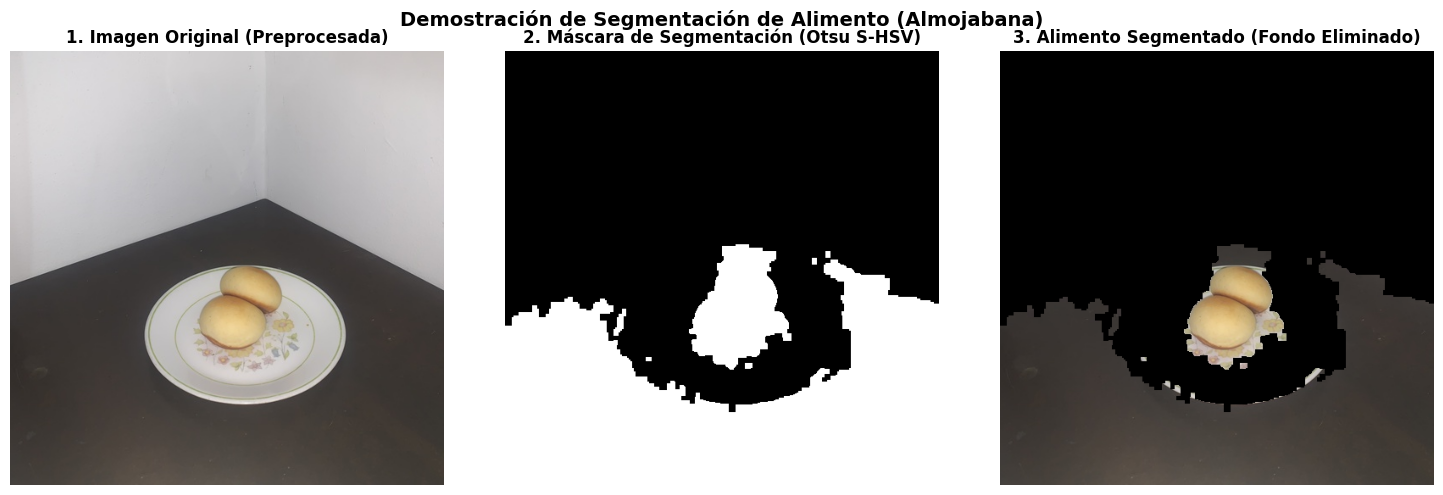

✅ Segmentación completada y verificada visualmente.


In [5]:
# Tomar una imagen de muestra para demostrar la segmentación
sample_cat = categories[0]  # Almojábana
sample_dir = PROCESSED_DIR / "train" / sample_cat
sample_path = list(sample_dir.glob("*.jpg"))[0]
img_sample = Image.open(sample_path)
img_np = np.array(img_sample)

# Convertir a HSV
hsv_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
s_channel = hsv_img[:, :, 1]

# Umbralización de Otsu sobre el canal de saturación
_, mask = cv2.threshold(s_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Limpieza morfológica de la máscara
kernel = np.ones((5, 5), np.uint8)
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel)

# Aplicar máscara a la imagen original
segmented_result = cv2.bitwise_and(img_np, img_np, mask=mask_clean)

# Mostrar los resultados visualmente (Criterio de Rubro)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_np)
axes[0].set_title("1. Imagen Original (Preprocesada)", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mask_clean, cmap='gray')
axes[1].set_title("2. Máscara de Segmentación (Otsu S-HSV)", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(segmented_result)
axes[2].set_title("3. Alimento Segmentado (Fondo Eliminado)", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.suptitle(f"Demostración de Segmentación de Alimento ({sample_cat})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Segmentación completada y verificada visualmente.")

## 5. Extracción Tradicional de Características (Color + Textura + Forma) y Entrenamiento ML

In [6]:
def extract_features_from_image(img_path):
    pil_img = Image.open(img_path)
    if pil_img.mode != "RGB":
        pil_img = pil_img.convert("RGB")
    bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    
    # 1. Color HSV
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hsv_hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    hsv_hist = cv2.normalize(hsv_hist, hsv_hist).flatten()
    
    # 2. Color Lab
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    hist_l = cv2.calcHist([lab], [0], None, [16], [0, 256])
    hist_a = cv2.calcHist([lab], [1], None, [16], [0, 256])
    hist_b = cv2.calcHist([lab], [2], None, [16], [0, 256])
    lab_hist = np.concatenate([hist_l, hist_a, hist_b]).flatten()
    lab_hist = lab_hist / (lab_hist.sum() + 1e-7)
    
    # 3. Textura LBP
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=24, R=3, method="uniform")
    n_bins = 26
    lbp_hist, _ = np.histogram(lbp.ravel(), density=True, bins=n_bins, range=(0, n_bins))
    
    # 4. Descriptores HOG
    gray_128 = cv2.resize(gray, (128, 128))
    hog_feat = hog(gray_128, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm='L2-Hys')
    
    return np.concatenate([hsv_hist, lab_hist, lbp_hist, hog_feat])

print("Extractor de características HSV + Lab + LBP + HOG configurado.")

Extractor de características HSV + Lab + LBP + HOG configurado.


### Carga de Vectores de Características y Evaluación ML

In [7]:
def load_split_features(split_name, categories):
    X, y = [], []
    for c_idx, cat in enumerate(categories):
        folder = PROCESSED_DIR / split_name / cat
        for img_p in folder.glob("*.jpg"):
            X.append(extract_features_from_image(img_p))
            y.append(c_idx)
    return np.array(X), np.array(y)

X_train, y_train = load_split_features("train", categories)
X_val, y_val = load_split_features("val", categories)
X_test, y_test = load_split_features("test", categories)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_te_scaled = scaler.transform(X_test)

models_dict = {
    "SVM (RBF Kernel)": SVC(kernel="rbf", C=10.0, probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, eval_metric="mlogloss", random_state=42)
}

benchmark_results = []
for name, model in models_dict.items():
    model.fit(X_tr_scaled, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_te_scaled))
    benchmark_results.append({"Modelo": name, "Val Accuracy (%)": val_acc*100, "Test Accuracy (%)": test_acc*100})

df_results = pd.DataFrame(benchmark_results)
print("📊 Resultados de Modelos Tradicionales:")
print(df_results)

📊 Resultados de Modelos Tradicionales:
             Modelo  Val Accuracy (%)  Test Accuracy (%)
0  SVM (RBF Kernel)         31.914894             43.750
1     Random Forest         48.936170             46.875
2           XGBoost         51.063830             43.750


### 📊 Análisis de Aporte Discriminativo de las Características (Criterio de Rubro)

Para evaluar cuantitativamente el aporte de cada tipo de descriptor (Color, Textura y Forma) en la clasificación, calculamos la importancia acumulada de las características usando el clasificador **Random Forest** entrenado.

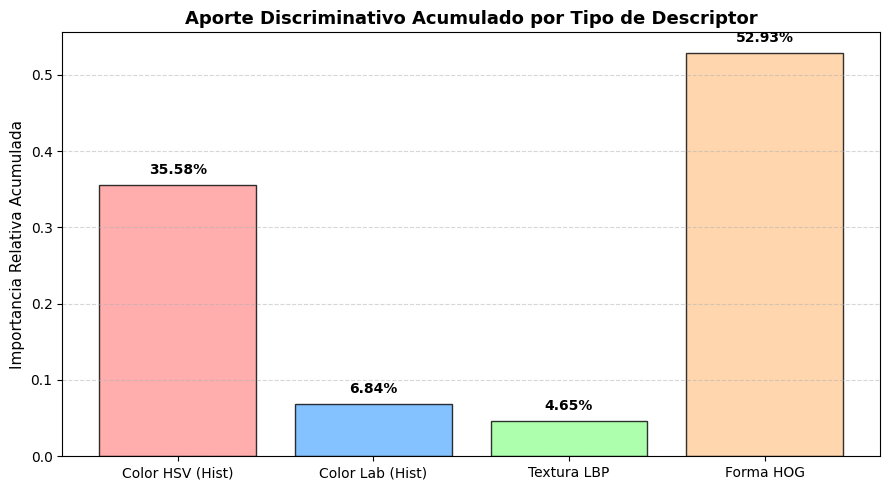

✅ Análisis del aporte discriminativo completado.


In [8]:
# Obtener las importancias del Random Forest entrenado
rf_model = models_dict["Random Forest"]
importances = rf_model.feature_importances_

# Definir las dimensiones de cada descriptor
hsv_dim = 512   # Color HSV Hist
lab_dim = 48    # Color Lab Hist
lbp_dim = 26    # Textura LBP
hog_dim = 1568  # Forma HOG

# Sumar importancias por tipo de descriptor
hsv_imp = importances[:hsv_dim].sum()
lab_imp = importances[hsv_dim:hsv_dim + lab_dim].sum()
lbp_imp = importances[hsv_dim + lab_dim:hsv_dim + lab_dim + lbp_dim].sum()
hog_imp = importances[hsv_dim + lab_dim + lbp_dim:].sum()

# Graficar los aportes discriminativos
plt.figure(figsize=(9, 5))
feat_types = ["Color HSV (Hist)", "Color Lab (Hist)", "Textura LBP", "Forma HOG"]
feat_imps = [hsv_imp, lab_imp, lbp_imp, hog_imp]
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']

bars = plt.bar(feat_types, feat_imps, color=colors, edgecolor='black', alpha=0.8)
plt.ylabel("Importancia Relativa Acumulada", fontsize=11)
plt.title("Aporte Discriminativo Acumulado por Tipo de Descriptor", fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval*100:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Análisis del aporte discriminativo completado.")

## 6. Enfoque 2: Optimización de Hiperparámetros (Optuna) y Entrenamiento Extendido (25 Épocas)

In [9]:
# Cargar resultados del estudio de Optuna y modelo optimizado
optuna_res_path = Path("models/cnn_optuna_results.json")
if optuna_res_path.exists():
    with open(optuna_res_path, "r", encoding="utf-8") as f:
        res = json.load(f)
    print("🎯 Resultados de Optimización de Hiperparámetros (Optuna):")
    print(f"- Épocas de Entrenamiento Final: {res['epochs']}")
    print(f"- Mejor Precisión en Validación: {res['best_val_accuracy']*100:.2f}%")
    print(f"- Precisión Final en Test Set:   {res['test_accuracy']*100:.2f}%")
    print("\n⚙️ Mejores Hiperparámetros Encontrados:")
    for k, v in res['best_params'].items():
        print(f"  • {k}: {v}")

### Gráfica de Curvas de Aprendizaje (Pérdida y Precisión durante 25 Épocas)

In [10]:
if optuna_res_path.exists():
    hist = res['history']
    epochs_range = range(1, len(hist['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pérdida (Loss)
    ax1.plot(epochs_range, hist['train_loss'], 'b-o', label='Train Loss')
    ax1.plot(epochs_range, hist['val_loss'], 'r-s', label='Val Loss')
    ax1.set_title('Curva de Pérdida (Loss)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('CrossEntropy Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Precisión (Accuracy)
    ax2.plot(epochs_range, [a * 100 for a in hist['train_acc']], 'b-o', label='Train Accuracy')
    ax2.plot(epochs_range, [a * 100 for a in hist['val_acc']], 'r-s', label='Val Accuracy')
    ax2.set_title('Curva de Precisión (%)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Precisión (%)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.suptitle('🇨🇴 Curvas de Entrenamiento CNN Optimizada (25 Épocas)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 7. Matriz de Confusión Final (Test Set)

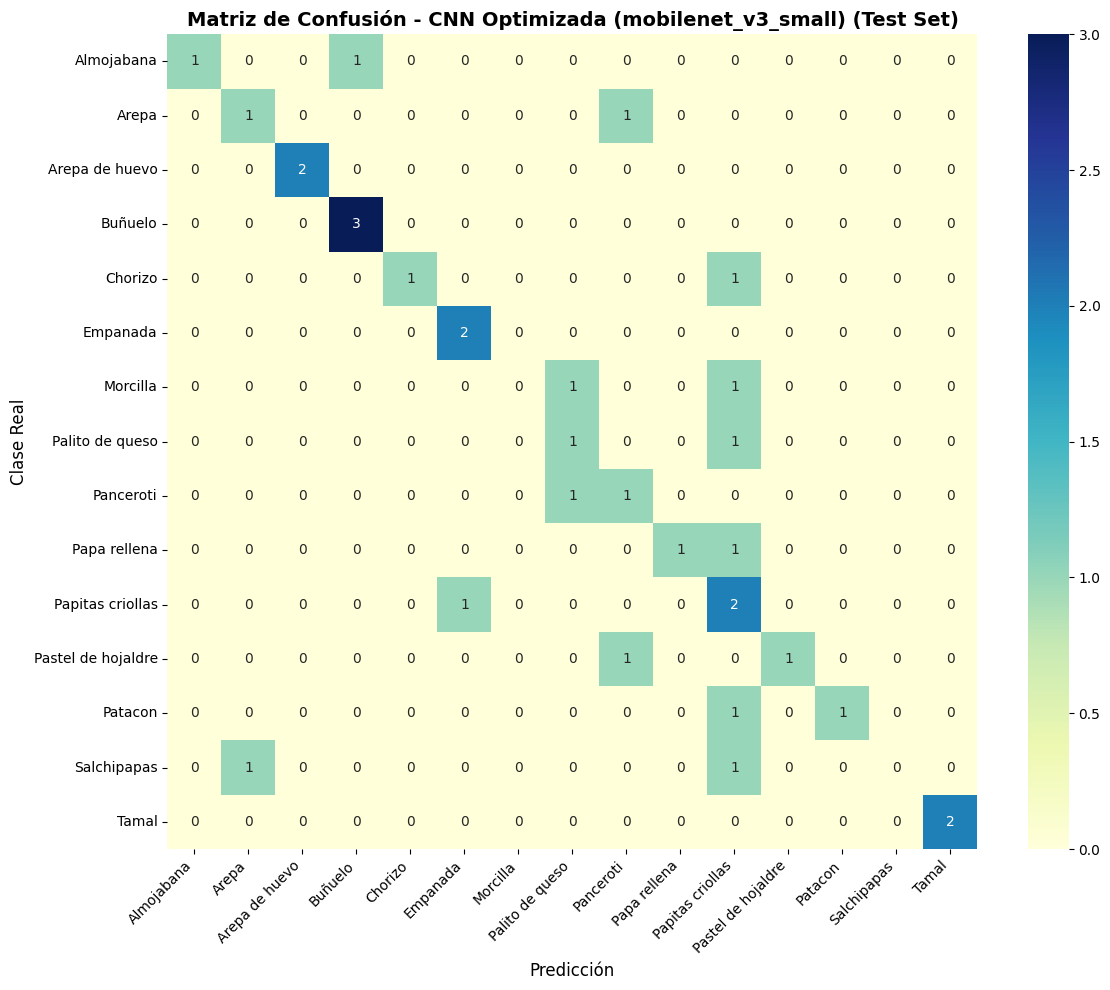

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = Path("models/best_cnn_model.pth")

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_name = checkpoint.get('model_name', 'mobilenet_v3_small')
    best_params = checkpoint.get('best_params', {})
    
    if model_name == 'mobilenet_v3_small':
        model_cnn = models.mobilenet_v3_small()
        if 'best_params' in checkpoint:
            dropout_rate = checkpoint['best_params'].get('dropout_rate', 0.2)
            model_cnn.classifier[2] = nn.Dropout(p=dropout_rate)
        model_cnn.classifier[3] = nn.Linear(model_cnn.classifier[3].in_features, len(categories))
    else:
        model_cnn = models.resnet18()
        in_features = model_cnn.fc.in_features
        if 'fc.1.weight' in checkpoint['state_dict']:
            dropout_rate = checkpoint.get('best_params', {}).get('dropout_rate', 0.2)
            model_cnn.fc = nn.Sequential(
                nn.Dropout(p=dropout_rate),
                nn.Linear(in_features, len(categories))
            )
        else:
            model_cnn.fc = nn.Linear(in_features, len(categories))
        
    model_cnn.load_state_dict(checkpoint['state_dict'])
    model_cnn.to(device)
    model_cnn.eval()
    
    cnn_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    dataset_test = datasets.ImageFolder(PROCESSED_DIR / "test", cnn_transform)
    test_loader = DataLoader(dataset_test, batch_size=16, shuffle=False)
    
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model_cnn(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    cm = confusion_matrix(all_targets, all_preds)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=categories, yticklabels=categories)
    plt.title(f"Matriz de Confusión - CNN Optimizada ({model_name}) (Test Set)", fontsize=14, fontweight='bold')
    plt.xlabel("Predicción", fontsize=12)
    plt.ylabel("Clase Real", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()